In [40]:
import numpy as np
import matplotlib.pyplot as plt

import ismrmrd
import torch

import psutil
import subprocess
import os
import h5py  

import lxml.etree

In [41]:
CarryOutSim = True

In [42]:
# Flip angle (hard coded in the sequence xml file)
Flip_angle  = 120 
print("The flip angle is:", Flip_angle, "degrees (currently hard coded)") 

The flip angle is: 120 degrees (currently hard coded)


In [43]:
iNump = psutil.cpu_count(logical=False)

if CarryOutSim:
    os.chdir('CP_test')
    subprocess.run(["mpirun", "-np", str(iNump), "pjemris", "simu_HardPulse.xml"])
    os.chdir('..')
    os.rename('CP_test/signals_ismrmrd.h5', 'CP_test/signals_ismrmrd_FA1.h5')


Parallel jemris 2.9.2 (b0b3084267c41df80e4799beb7378060a0b8f60d)

Model    : Bloch	  , solver = CVODE
Sample   : user defined	  , spins  = 17645
TxArray  : 8chheadcyl.xml
RxArray  : /usr/local/share/jemris/matlab/uniform.xml
Sequence : gre_CP_HardPulse.xml

Mac.fritz.box -> Master Process: send MR sample (17645 spins) to 11 slave(s)

Simulating | ************************************************** | 100% done

Actual simulation took 125.23 seconds.


In [44]:
dset = ismrmrd.Dataset('CP_test/signals_ismrmrd_FA1.h5', 'dataset', create_if_needed=False)

In [45]:
# extract the header
header = ismrmrd.xsd.CreateFromDocument(dset.read_xml_header())
enc = header.encoding[0]

# Matrix size
eNx = enc.encodedSpace.matrixSize.x
eNy = enc.encodedSpace.matrixSize.y
eNz = enc.encodedSpace.matrixSize.z
rNx = enc.reconSpace.matrixSize.x
rNy = enc.reconSpace.matrixSize.y
rNz = enc.reconSpace.matrixSize.z

if(header.acquisitionSystemInformation.systemVendor == 'JEMRIS'):
    # Adjust for JEMRIS double matrix size bug
    # eNx = eNx // 2
    # eNy = eNy // 2
    # eNz = eNz // 2
    # rNx = rNx // 2
    # rNy = rNy // 2
    # rNz = rNz // 2
    if(eNx==0):
        eNx = 1
    if(eNy==0):
        eNy = 1
    if(eNz==0):
        eNz = 1
    if(rNx==0):
        rNx = 1
    if(rNy==0):
        rNy = 1
    if(rNz==0):
        rNz = 1
        
# Field of View
eFOVx = enc.encodedSpace.fieldOfView_mm.x
eFOVy = enc.encodedSpace.fieldOfView_mm.y
eFOVz = enc.encodedSpace.fieldOfView_mm.z
rFOVx = enc.reconSpace.fieldOfView_mm.x
rFOVy = enc.reconSpace.fieldOfView_mm.y
rFOVz = enc.reconSpace.fieldOfView_mm.z

# Number of Slices, Reps, Contrasts, etc.
if header.acquisitionSystemInformation.receiverChannels != None:        # Attention: This flag is not handled correctly by JEMRIS. We will treat this later.
    ncoils = header.acquisitionSystemInformation.receiverChannels
else:
    ncoils = 1

if enc.encodingLimits.slice != None:
    nslices = enc.encodingLimits.slice.maximum + 1
else:
    nslices = 1

if enc.encodingLimits.repetition != None:
    nreps = enc.encodingLimits.repetition.maximum + 1
else:
    nreps = 1

if enc.encodingLimits.set != None:
    nsets = enc.encodingLimits.set.maximum + 1
else:
    nsets = 1

if enc.encodingLimits.contrast != None:
    ncontrasts = enc.encodingLimits.contrast.maximum + 1
else:
    ncontrasts = 1

print('Parameters dertermined from the raw data file:')
print('FOV (x,y,z) = {},{},{}'.format(rFOVx, rFOVy, rFOVz))
print('Encoding matrix size (x,y,z) = {},{},{}'.format(eNx, eNy, eNz))
print('Image matrix size (x,y,z) = {},{},{}'.format(rNx, rNy, rNz))
print('Number of coils = {}'.format(ncoils))
print('Number of slices = {}'.format(nslices))
print('Number of repetitions = {}'.format(nreps))
print('Number of sets = {}'.format(nsets))
print('Number of contrasts = {}'.format(ncontrasts))

Parameters dertermined from the raw data file:
FOV (x,y,z) = 220.0,220.0,1.0
Encoding matrix size (x,y,z) = 64,64,1
Image matrix size (x,y,z) = 64,64,1
Number of coils = 1
Number of slices = 1
Number of repetitions = 1
Number of sets = 1
Number of contrasts = 1


In [46]:
# TODO loop through the acquisitions looking for noise scans
firstacq=0
for acqnum in range(dset.number_of_acquisitions()):

    acq = dset.read_acquisition(acqnum)
    
    # TODO: Currently ignoring noise scans
    if acq.isFlagSet(ismrmrd.ACQ_IS_NOISE_MEASUREMENT):
        print("Found noise scan at acq ", acqnum)
        continue
    else:
        firstacq = acqnum
        print("Imaging acquisition starts at acq ", acqnum)
        break

print('Numer of imaging k-sapce lines in the acquistion is {}'.format(dset.number_of_acquisitions()-firstacq))

Imaging acquisition starts at acq  0
Numer of imaging k-sapce lines in the acquistion is 65


In [47]:
# Get number of lines from header
nlines = (dset.number_of_acquisitions()-firstacq-1) 

acq = dset.read_acquisition(firstacq+1)
nsamples = len(acq.data[0])

# We are expecting nsets * ncontrasts * eNy data sets
nlines_expected = nsets * ncontrasts * eNy

if nlines != nlines_expected:
    firstacq = nlines - nlines_expected
    nlines = nlines_expected
    print("Start of imaging acquisition adopted to ", firstacq)
    print('Numer of imaging k-sapce lines in the acquistion adopted to {}'.format(dset.number_of_acquisitions()-firstacq))

print('Number of qcquistion lines reduced to {}'.format(nlines))
print('Number of samples per line is {}'.format(nsamples))

Number of qcquistion lines reduced to 64
Number of samples per line is 64


In [48]:
# Read first data line and get shape
acq = dset.read_acquisition(firstacq+1)
if np.ndim(acq.data) == 2:
    ncoils = acq.data.shape[0]
    if ncoils > 1:
        print('Receive coil array detected: \n\tThe header information for coil arrays is not set by JEMRIS, so that a coil array con only be detected using the k-spae data shape.')
        print('This data has {} receive channels. Adjusted ncoils accordingly.'.format(ncoils))

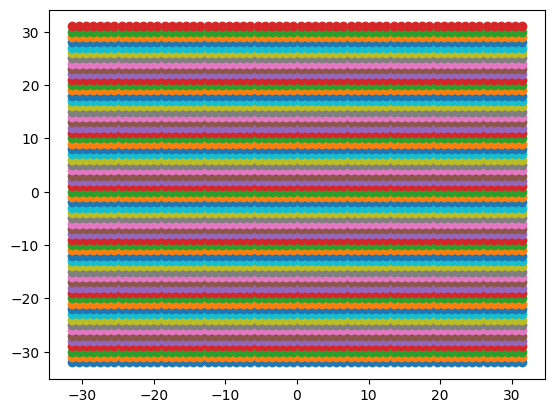

In [49]:
# Plot k-space lines
fig = plt.figure()
ax = plt.axes()

# Loop through the rest of the acquisitions and plot lines
for acqnum in range(firstacq + 1,dset.number_of_acquisitions()): 
    acq = dset.read_acquisition(acqnum)
    ax.scatter(acq.traj[:,0], acq.traj[:,1])
    # print('Acqnum {} has shape {}'.format(acqnum, acq.traj[:,0].shape[0]))

In [50]:
# preallocate storrage
all_data = np.zeros( (nlines, ncoils, nsamples), dtype=np.complex64 )
all_kspace = np.zeros( (nlines, nsamples, 3), dtype=np.complex64 )

# assign
for acqnum in range(firstacq + 1, dset.number_of_acquisitions()):
    acq = dset.read_acquisition(acqnum)
    all_data[acqnum-firstacq-1,:] = acq.data
    all_kspace[acqnum-firstacq-1,:,:] = acq.traj

In [51]:
dset.close()
rawdata = np.squeeze(all_data[:,0,:])

In [52]:
# fftshift FFT fftshift
spectrum = torch.fft.fftshift(torch.from_numpy(rawdata))
space = torch.fft.fft2(spectrum)
space_FA1 = torch.fft.ifftshift(space)


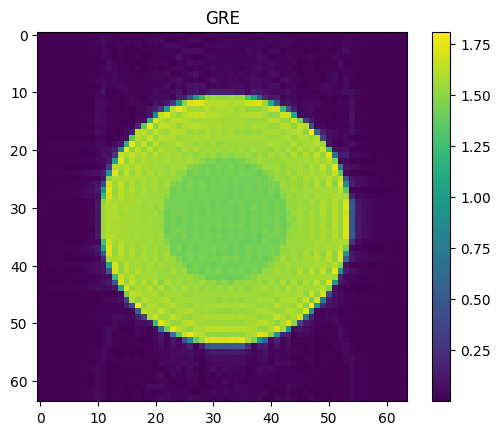

In [53]:
plt.title('GRE')
plt.imshow(np.abs(space_FA1.numpy()))
plt.colorbar()

In [54]:
iNump = psutil.cpu_count(logical=False)

if CarryOutSim:
    os.chdir('CP_test')
    subprocess.run(["mpirun", "-np", str(iNump), "pjemris", "simu_HardPulse_DA.xml"])
    os.chdir('..')
    os.rename('CP_test/signals_ismrmrd.h5', 'CP_test/signals_ismrmrd_FA2.h5')


Parallel jemris 2.9.2 (b0b3084267c41df80e4799beb7378060a0b8f60d)

Model    : Bloch	  , solver = CVODE
Sample   : user defined	  , spins  = 17645
TxArray  : 8chheadcyl.xml
RxArray  : /usr/local/share/jemris/matlab/uniform.xml
Sequence : gre_CP_HardPulse_DA.xml

Mac.fritz.box -> Master Process: send MR sample (17645 spins) to 11 slave(s)

Simulating | ************************************************** | 100% done

Actual simulation took 361.74 seconds.


In [55]:
dset = ismrmrd.Dataset('CP_test/signals_ismrmrd_FA2.h5', 'dataset', create_if_needed=False)

In [56]:
# extract the header
header = ismrmrd.xsd.CreateFromDocument(dset.read_xml_header())
enc = header.encoding[0]

# Matrix size
eNx = enc.encodedSpace.matrixSize.x
eNy = enc.encodedSpace.matrixSize.y
eNz = enc.encodedSpace.matrixSize.z
rNx = enc.reconSpace.matrixSize.x
rNy = enc.reconSpace.matrixSize.y
rNz = enc.reconSpace.matrixSize.z

if(header.acquisitionSystemInformation.systemVendor == 'JEMRIS'):
    # Adjust for JEMRIS double matrix size bug
    # eNx = eNx // 2
    # eNy = eNy // 2
    # eNz = eNz // 2
    # rNx = rNx // 2
    # rNy = rNy // 2
    # rNz = rNz // 2
    if(eNx==0):
        eNx = 1
    if(eNy==0):
        eNy = 1
    if(eNz==0):
        eNz = 1
    if(rNx==0):
        rNx = 1
    if(rNy==0):
        rNy = 1
    if(rNz==0):
        rNz = 1
        
# Field of View
eFOVx = enc.encodedSpace.fieldOfView_mm.x
eFOVy = enc.encodedSpace.fieldOfView_mm.y
eFOVz = enc.encodedSpace.fieldOfView_mm.z
rFOVx = enc.reconSpace.fieldOfView_mm.x
rFOVy = enc.reconSpace.fieldOfView_mm.y
rFOVz = enc.reconSpace.fieldOfView_mm.z

# Number of Slices, Reps, Contrasts, etc.
if header.acquisitionSystemInformation.receiverChannels != None:        # Attention: This flag is not handled correctly by JEMRIS. We will treat this later.
    ncoils = header.acquisitionSystemInformation.receiverChannels
else:
    ncoils = 1

if enc.encodingLimits.slice != None:
    nslices = enc.encodingLimits.slice.maximum + 1
else:
    nslices = 1

if enc.encodingLimits.repetition != None:
    nreps = enc.encodingLimits.repetition.maximum + 1
else:
    nreps = 1

if enc.encodingLimits.set != None:
    nsets = enc.encodingLimits.set.maximum + 1
else:
    nsets = 1

if enc.encodingLimits.contrast != None:
    ncontrasts = enc.encodingLimits.contrast.maximum + 1
else:
    ncontrasts = 1

print('Parameters dertermined from the raw data file:')
print('FOV (x,y,z) = {},{},{}'.format(rFOVx, rFOVy, rFOVz))
print('Encoding matrix size (x,y,z) = {},{},{}'.format(eNx, eNy, eNz))
print('Image matrix size (x,y,z) = {},{},{}'.format(rNx, rNy, rNz))
print('Number of coils = {}'.format(ncoils))
print('Number of slices = {}'.format(nslices))
print('Number of repetitions = {}'.format(nreps))
print('Number of sets = {}'.format(nsets))
print('Number of contrasts = {}'.format(ncontrasts))

Parameters dertermined from the raw data file:
FOV (x,y,z) = 220.0,220.0,1.0
Encoding matrix size (x,y,z) = 64,64,1
Image matrix size (x,y,z) = 64,64,1
Number of coils = 1
Number of slices = 1
Number of repetitions = 1
Number of sets = 1
Number of contrasts = 1


In [57]:
# TODO loop through the acquisitions looking for noise scans
firstacq=0
for acqnum in range(dset.number_of_acquisitions()):

    acq = dset.read_acquisition(acqnum)
    
    # TODO: Currently ignoring noise scans
    if acq.isFlagSet(ismrmrd.ACQ_IS_NOISE_MEASUREMENT):
        print("Found noise scan at acq ", acqnum)
        continue
    else:
        firstacq = acqnum
        print("Imaging acquisition starts at acq ", acqnum)
        break

print('Numer of imaging k-sapce lines in the acquistion is {}'.format(dset.number_of_acquisitions()-firstacq))

Imaging acquisition starts at acq  0
Numer of imaging k-sapce lines in the acquistion is 65


In [58]:
# Get number of lines from header
nlines = (dset.number_of_acquisitions()-firstacq-1) 

acq = dset.read_acquisition(firstacq+1)
nsamples = len(acq.data[0])

# We are expecting nsets * ncontrasts * eNy data sets
nlines_expected = nsets * ncontrasts * eNy

if nlines != nlines_expected:
    firstacq = nlines - nlines_expected
    nlines = nlines_expected
    print("Start of imaging acquisition adopted to ", firstacq)
    print('Numer of imaging k-sapce lines in the acquistion adopted to {}'.format(dset.number_of_acquisitions()-firstacq))

print('Number of qcquistion lines reduced to {}'.format(nlines))
print('Number of samples per line is {}'.format(nsamples))

Number of qcquistion lines reduced to 64
Number of samples per line is 64


In [59]:
# Read first data line and get shape
acq = dset.read_acquisition(firstacq+1)
if np.ndim(acq.data) == 2:
    ncoils = acq.data.shape[0]
    if ncoils > 1:
        print('Receive coil array detected: \n\tThe header information for coil arrays is not set by JEMRIS, so that a coil array con only be detected using the k-spae data shape.')
        print('This data has {} receive channels. Adjusted ncoils accordingly.'.format(ncoils))

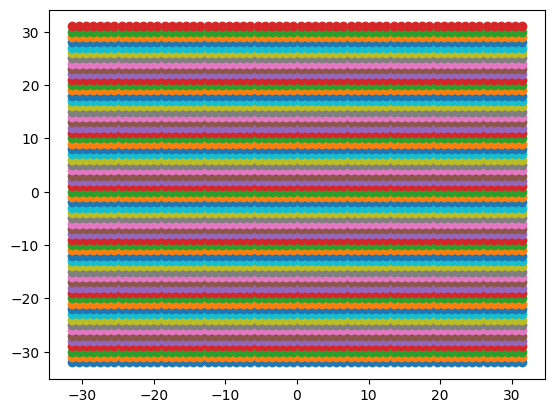

In [60]:
# Plot k-space lines
fig = plt.figure()
ax = plt.axes()

# Loop through the rest of the acquisitions and plot lines
for acqnum in range(firstacq + 1,dset.number_of_acquisitions()): 
    acq = dset.read_acquisition(acqnum)
    ax.scatter(acq.traj[:,0], acq.traj[:,1])
    # print('Acqnum {} has shape {}'.format(acqnum, acq.traj[:,0].shape[0]))

In [61]:
# preallocate storrage
all_data = np.zeros( (nlines, ncoils, nsamples), dtype=np.complex64 )
all_kspace = np.zeros( (nlines, nsamples, 3), dtype=np.complex64 )

# assign
for acqnum in range(firstacq + 1, dset.number_of_acquisitions()):
    acq = dset.read_acquisition(acqnum)
    all_data[acqnum-firstacq-1,:] = acq.data
    all_kspace[acqnum-firstacq-1,:,:] = acq.traj

In [62]:
dset.close()
rawdata = np.squeeze(all_data[:,0,:])

In [63]:
# fftshift FFT fftshift
spectrum = torch.fft.fftshift(torch.from_numpy(rawdata))
space = torch.fft.fft2(spectrum)
space_FA2 = torch.fft.ifftshift(space)


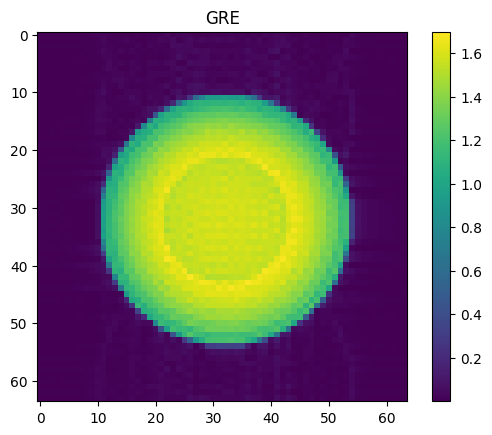

In [64]:
plt.title('GRE')
plt.imshow(np.abs(space_FA2.numpy()))
plt.colorbar()

In [65]:
# compute FA map
r = np.abs(space_FA1.numpy())/np.abs(space_FA2.numpy())
FA_map = np.arccos(1/(2*r))
FA_map[~np.isfinite(FA_map)] = 0 

/var/folders/x0/stdn8c895h99g4y89x6mmbvm0015kg/T/ipykernel_5950/3363120014.py:3: RuntimeWarning: invalid value encountered in arccos
  FA_map = np.arccos(1/(2*r))


In [66]:
thresh = 0.1
Mask = np.zeros_like(FA_map)
Mask[np.abs(space_FA2.numpy()) > thresh * np.max(np.abs(space_FA2.numpy()))] = 1.0

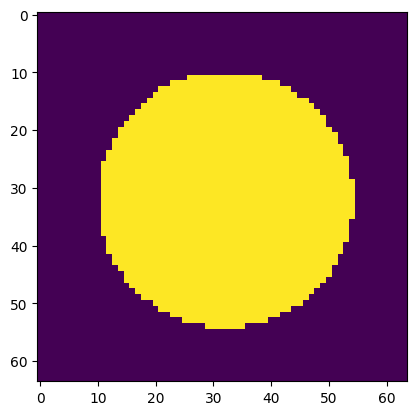

In [67]:
plt.imshow(Mask)

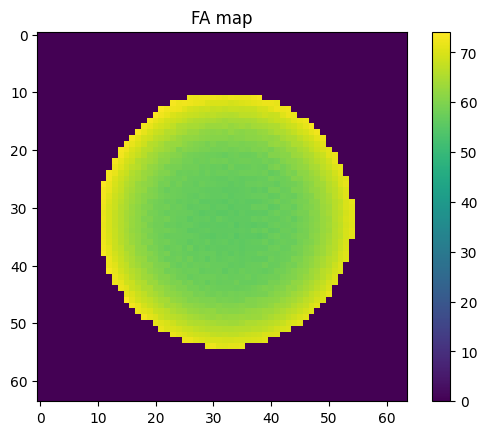

In [78]:
plt.title('FA map')
plt.imshow(FA_map*180/np.pi * Mask)
plt.colorbar()

In [69]:
meanFA = np.mean(FA_map[Mask==1.0]*180/np.pi)
print('Mean FA in the masked area is {} degrees.'.format(meanFA))

Mean FA in the masked area is 62.49822998046875 degrees.


In [70]:
import sys
import platform

from scipy.io import loadmat

In [71]:
%load_ext autoreload
%autoreload 2
home = os.path.expanduser("~")
if platform.system() == 'Linux':
    sys.path.insert(0, os.path.join( home, 'coil-evaluations') )
elif platform.system() == 'Windows':
    sys.path.insert(0, os.path.join( '/Users/jfelder/Documents/Python Scripts' , 'coil-evaluations') )
elif platform.system() == 'Darwin':
    sys.path.insert(0, os.path.join( '/Users/jfelder/Documents/python' , 'coil-evaluations') )

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [72]:
from helper.helper import ResampleImage

In [73]:
d = loadmat('CP_test/8chheadcyl.fig', squeeze_me=True, struct_as_record=False)
matfig = d['hgS_070000']

In [74]:
XData = matfig.children.children[0].properties.XData
YData = matfig.children.children[0].properties.YData
CData = matfig.children.children[0].properties.CData

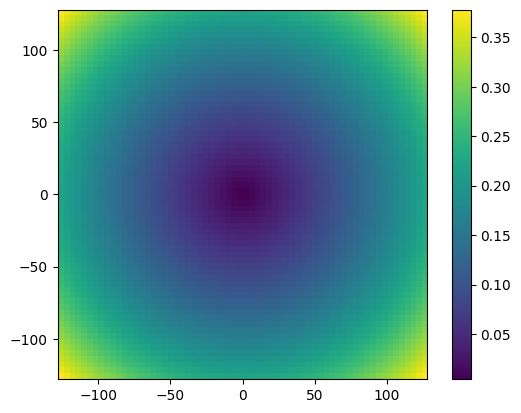

In [75]:
plt.imshow(CData, extent=(XData.min(), XData.max(), YData.min(), YData.max()), origin='lower')
plt.colorbar()

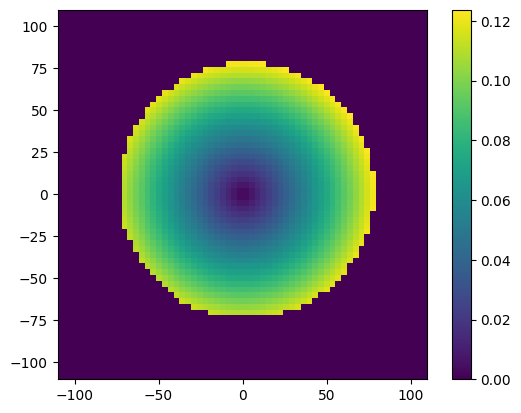

In [76]:
Sens_map = ResampleImage(CData, XData, YData, np.linspace(-rFOVx/2, rFOVx/2, rNx), np.linspace(-rFOVy/2, rFOVy/2, rNy))
plt.imshow(Sens_map*Mask, extent=(-rFOVx/2, rFOVx/2, -rFOVy/2, rFOVy/2), origin='lower')
plt.colorbar()

In [77]:
Average_B1_plus = np.mean(CData[Mask==1.0])
print('Average B1+ in the masked area is {} (arbitrary units).'.format(Average_B1_plus))
print('Average scaling factor for the flip angle is {} (arbitrary units).'.format(np.sqrt(1/Average_B1_plus)))

Average B1+ in the masked area is 0.09131699763864719 (arbitrary units).
Average scaling factor for the flip angle is 3.3092089324734117 (arbitrary units).
